### Validating the clusters

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
dataset= pd.read_csv('workforce_1000.csv')

# Same 4 features used in Layer 1
features = ['satisfaction_score', 'productivity_baseline',
            'resistance_propensity', 'training_times_yr']

scaler= StandardScaler()
X_scaled= scaler.fit_transform(dataset[features])

kmeans= KMeans(n_clusters=5, random_state=42, n_init=20)
clusters=kmeans.fit_predict(X_scaled)

# Check if cluster assignments match existing persona labels
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                         columns=features)
print(centroids.sort_values('resistance_propensity'))
print(f'\nCluster sizes: {np.bincount(clusters)}')

   satisfaction_score  ...  training_times_yr
1            7.902299  ...           2.534483
3            7.925425  ...           2.264264
0            6.782561  ...           5.099338
4            5.730874  ...           2.500000
2            5.509592  ...           2.460432

[5 rows x 4 columns]

Cluster sizes: [151 116 277 334 122]


#### Measuring the Silhoutte Score to check if the clusters are internally coherent
- formula to calculate it:
    - Compute the average distance of each agent to all others in its cluster (cohesion, a(i)).
    - Compute the average distance to the nearest cluster (separation, b(i)). 
    - Calculate the silhouette score per agent: s(i) = (b(i) – a(i)) / max(a(i), b(i)).
    - Take the mean across all agents for an overall score. 

#### Davies Bouldin Score- checks if the clusters are well-seperated from each other
- below 1.0 means they are genuinly distinct
- above 1.0 means they are kinda overlapping

In [9]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

sil_score= silhouette_score(X_scaled, clusters)
print(f'Silhouette Score: {sil_score:.4f}')


Silhouette Score: 0.2337


- the silhouette score is below 0.35.
    - the clustering features dont seperate personas well
    - the ibm hr columns are too correlated
- FIX: Adding digital dexterity as a 5th clustering feature

In [10]:
features_new= ['satisfaction_score', 'productivity_baseline',
               'resistance_propensity', 'training_times_yr',
               'digital_dexterity']
X_scaled_new= scaler.fit_transform(dataset[features_new])
kmeans_new= KMeans(n_clusters=5, random_state=42, n_init=20)

clusters_new= kmeans_new.fit_predict(X_scaled_new)
sil_score_new= silhouette_score(X_scaled_new, clusters_new)
davies_bouldin_new= davies_bouldin_score(X_scaled_new, clusters_new)


print(f'Silhouette Score (5 features): {sil_score_new:.4f}')
print(f'Davies-Bouldin Score (5 features): {davies_bouldin_new:.4f}')


Silhouette Score (5 features): 0.2854
Davies-Bouldin Score (5 features): 1.2508


k=2  |  Silhouette: 0.2706  |  Inertia: 3773.0
k=3  |  Silhouette: 0.2800  |  Inertia: 2830.9
k=4  |  Silhouette: 0.3021  |  Inertia: 2322.0
k=5  |  Silhouette: 0.2854  |  Inertia: 2084.5
k=6  |  Silhouette: 0.2522  |  Inertia: 1955.7
k=7  |  Silhouette: 0.2451  |  Inertia: 1832.9


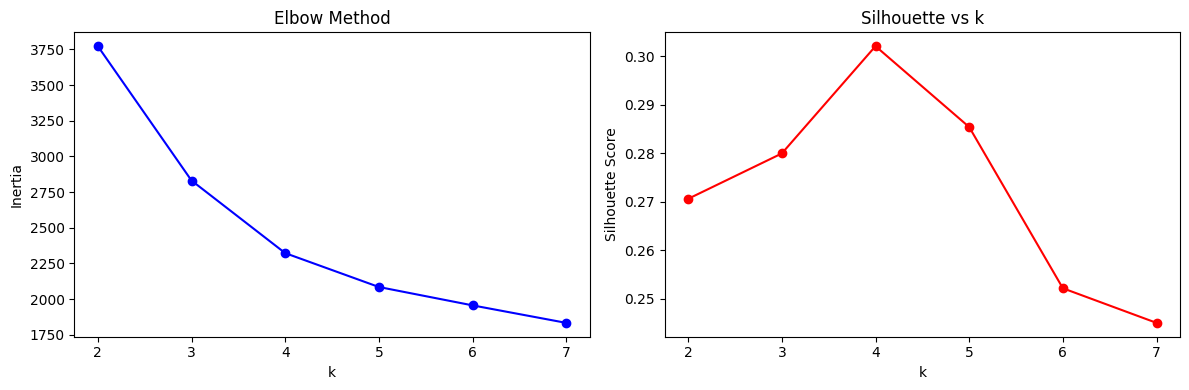

In [ ]:
import matplotlib.pyplot as plt

inertias = []   # within cluster distance
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled_new)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_new, labels))
    print(f'k={k}  |  Silhouette: {sil_scores[-1]:.4f}  |  Inertia: {inertias[-1]:.1f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette vs k')
plt.tight_layout()
plt.show()


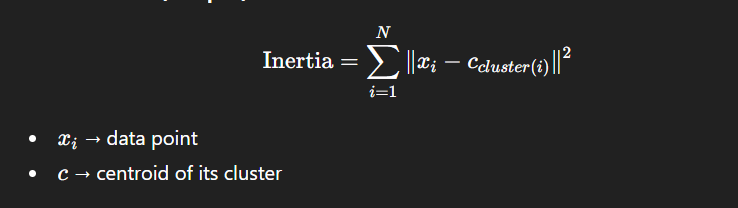

In [13]:
features_new= ['satisfaction_score', 'productivity_baseline',
               'resistance_propensity', 'training_times_yr',
               'digital_dexterity']
X_scaled_new= scaler.fit_transform(dataset[features_new])
kmeans_new= KMeans(n_clusters=4, random_state=42, n_init=20)

clusters_new= kmeans_new.fit_predict(X_scaled_new)
sil_score_new= silhouette_score(X_scaled_new, clusters_new)
davies_bouldin_new= davies_bouldin_score(X_scaled_new, clusters_new)


print(f'Silhouette Score (5 features): {sil_score_new:.4f}')
print(f'Davies-Bouldin Score (5 features): {davies_bouldin_new:.4f}')


Silhouette Score (5 features): 0.3021
Davies-Bouldin Score (5 features): 1.1700


fixing the dataset now. in data.ipynb